#Line detection by Hough transform
The Hough Line Transform is a transform used to detect straight lines.
To apply the Transform, first an edge detection pre-processing is desirable

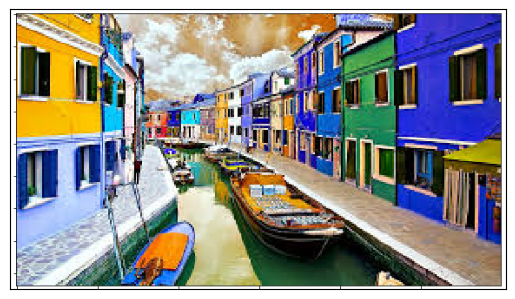

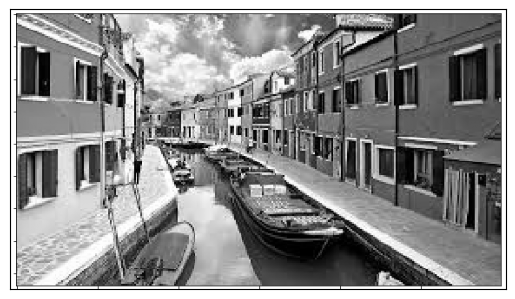

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = cv2.imread('burano.png', cv2.IMREAD_COLOR)
#img = cv2.imread('shapes-01.jpeg')
img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
imgplot = plt.imshow(img)
plt.show(plt.xticks([]), plt.yticks([]))

#convert the color image in grayscale
img_gray=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img_gray, cmap = 'gray');
plt.show(plt.xticks([]), plt.yticks([]))

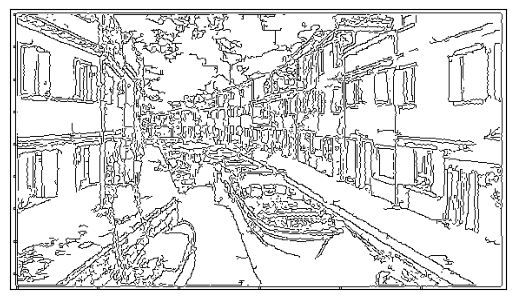

In [3]:
#Apply edge detection before applying hough transform.
# We find the edges in the image using Canny detector
#changing the threshold of the detector will affect the edges
t=40
T=300
#thresholds for burano image
#t=300
#T=400
edges=cv2.Canny(img_gray, t, T) # set the two thresholds

#edges=cv2.Canny(img_gray, 300, 400) # set the two thresholds
imgplot = plt.imshow(255-edges,cmap='gray')
plt.show(plt.xticks([]), plt.yticks([]))

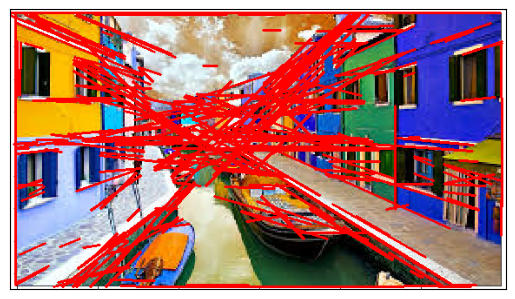

In [ ]:
# Apply HoughLinesP method to directly obtain line end points
lines = cv2.HoughLinesP(
            edges, # Input edge image
            1, # Distance resolution in pixels
            np.pi/180, # Angle resolution in radians
            threshold=90, # Min number of votes for valid line
            minLineLength=10, # Min allowed length of line
            maxLineGap=10 # Max allowed gap between line for joining them
            )

img_copy = img.copy()
# Iterate over points
for points in lines:
    # Extracted points nested in the list
    x1,y1,x2,y2=points[0]

    # Draw the lines joining the points on the original image
    cv2.line(img_copy,(x1,y1),(x2,y2),(255,0,0),2)


imgplot = plt.imshow(img_copy)
plt.show(plt.xticks([]), plt.yticks([]))